# Ejemplo de Aprendizaje Supervisado - Clasificación

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece la explicación de la creación de un modelo predictivo para una variable discreta.

Mantiene el uso de pipeline como buena práctica de la industria.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clasificacion/data_clientes_churn.csv

--2026-04-30 00:45:52--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/data_clasificacion/data_clientes_churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3366600 (3.2M) [text/plain]
Saving to: ‘data_clientes_churn.csv’

data_clientes_churn 100%[===================>]   3.21M  15.4MB/s    in 0.2s    

2026-04-30 00:45:53 (15.4 MB/s) - ‘data_clientes_churn.csv’ saved [3366600/3366600]



In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

In [46]:
data = pd.read_csv('data_clientes_churn.csv')
data.head()

,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn
0,23,1597,122.952046,12,26.264832,25.730656,10.161100,105.321777,4.865370,4.969036,premium,sur,email,negro,0
1,5,1173416,46.334513,-1,12.541970,19.554713,71.628916,43.180315,11.182667,9.490107,basic,sur,tv,verde,1
2,24,840852,26.117311,-5,3.564252,3.898365,42.272761,42.241841,2.843171,5.895103,premium,sur,email,negro,0
3,61,1125992,247.623150,0,12.681722,9.118614,52.288619,486.717389,49.563166,8.301565,vip,centro,tv,negro,0
4,50,931225,9.476443,9,26.848665,8.819610,146.862545,241.784867,14.233096,13.099419,basic,norte,email,negro,0


## Objetivo

Predecir si el cliente abandona o no la compañía, considerando `algunas` de sus características

In [4]:
target = "churn"

# Fase 2 - Entendimiento de los datos

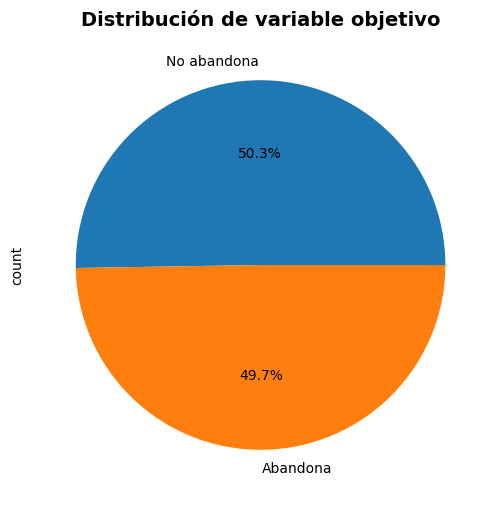

In [5]:
# Revisa la distribución de la variable objetivo
# En este caso se obtiene un gráfico de torta
data[target].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                 labels=['No abandona', 'Abandona'],
                                 figsize=(6, 6))
plt.title("Distribución de variable objetivo", fontsize=14, fontweight="bold")
plt.show()


## Detección de inconsistencias

In [6]:
data.dtypes

,0
antiguedad_cliente,int64
ingreso_mensual,int64
uso_app_minutos,float64
num_reclamos,int64
dias_desde_ultimo_login,float64
interacciones_soporte,float64
consumo_datos,float64
variacion_consumo,float64
pagos_atrasados,float64
score_satisfaccion,float64


In [7]:
# Detectar inconsistencias
inconsistentes = data[(data["antiguedad_cliente"] < 0) |
 (data["ingreso_mensual"] <= 0) | (data["uso_app_minutos"] < 0) |
  (data["num_reclamos"] < 0) | (data["dias_desde_ultimo_login"] < 0) |
(data["interacciones_soporte"] < 0) | (data["consumo_datos"] < 0) |
(data["pagos_atrasados"] < 0) | (data["score_satisfaccion"] < 0)
  ]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn
1,5,1173416,46.334513,-1,12.541970,19.554713,71.628916,43.180315,11.182667,9.490107,basic,sur,tv,verde,1
2,24,840852,26.117311,-5,3.564252,3.898365,42.272761,42.241841,2.843171,5.895103,premium,sur,email,negro,0
5,25,1019725,37.728806,-6,7.121071,1.847409,58.851414,52.747104,0.981530,11.632023,basic,norte,email,azul,0
6,45,1028761,111.217707,-10,25.871536,37.226613,139.374042,346.570592,2.193507,5.777623,premium,sur,email,verde,0
8,33,172106,68.245740,-16,30.301591,7.225171,54.564300,158.766779,4.222851,30.374895,basic,norte,tv,azul,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,14,-341674,188.801643,2,55.365158,32.076685,141.100148,208.073322,13.355510,2.287156,vip,norte,email,verde,0
19992,16,1371927,130.137446,-7,33.369482,14.795058,52.970532,61.023168,10.679087,10.307856,premium,norte,referido,azul,0
19993,41,1272617,39.944471,-4,16.977801,19.291741,129.632035,233.580628,19.573417,6.954355,premium,centro,referido,verde,1
19998,49,1748243,112.661749,-10,38.914172,23.051382,127.407233,479.774519,23.335922,8.866298,premium,sur,email,verde,1


In [8]:
for columna in ["plan", "region", "color_app_preferido", "canal_adquisicion"]:
  print("Valores: ", data[columna].unique())

Valores:  ['premium' 'basic' 'vip']
Valores:  ['sur' 'centro' 'norte']
Valores:  ['negro' 'verde' 'azul']
Valores:  ['email' 'tv' 'referido' 'instagram']


## Detección de nulos

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   antiguedad_cliente       20000 non-null  int64  
 1   ingreso_mensual          20000 non-null  int64  
 2   uso_app_minutos          20000 non-null  float64
 3   num_reclamos             20000 non-null  int64  
 4   dias_desde_ultimo_login  20000 non-null  float64
 5   interacciones_soporte    20000 non-null  float64
 6   consumo_datos            20000 non-null  float64
 7   variacion_consumo        20000 non-null  float64
 8   pagos_atrasados          20000 non-null  float64
 9   score_satisfaccion       20000 non-null  float64
 10  plan                     20000 non-null  object 
 11  region                   20000 non-null  object 
 12  canal_adquisicion        20000 non-null  object 
 13  color_app_preferido      20000 non-null  object 
 14  churn                 

## Detección de valores atípicos

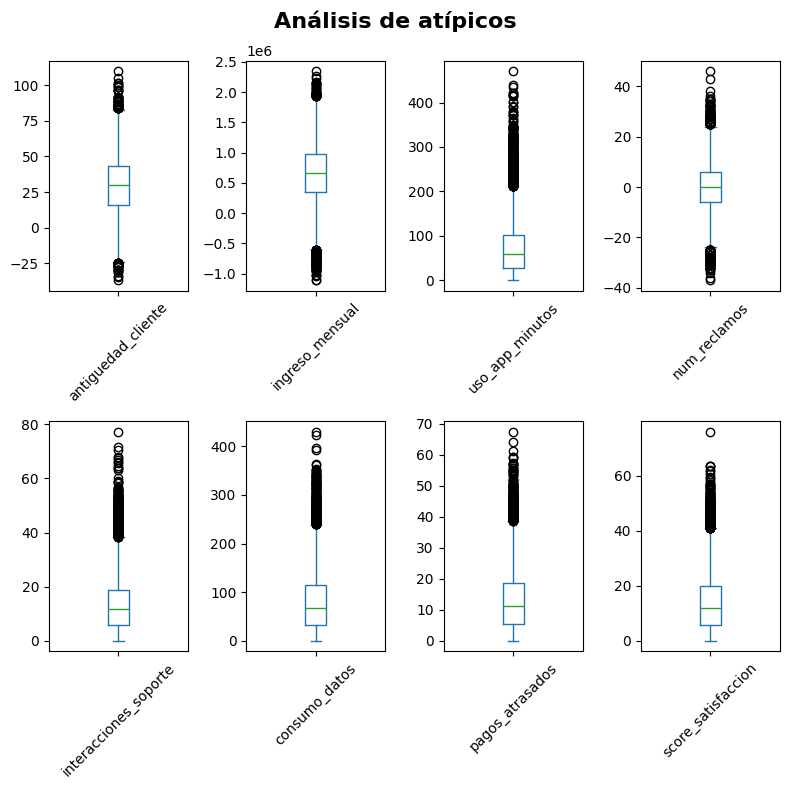

In [10]:
revision_atipicos = ["antiguedad_cliente", "ingreso_mensual", "uso_app_minutos", "num_reclamos",
 "interacciones_soporte", "consumo_datos", "pagos_atrasados",
 "score_satisfaccion"]
# Muestra los gráficos agrupados en 2 filas y 4 columnas
fig, axes = plt.subplots(2, int(len(revision_atipicos) / 2), figsize=(30,30))
#axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  if i < len(revision_atipicos) / 2:
    data[col].plot(kind='box',figsize=(8,8), ax=axes[0, i])
    axes[0, i].tick_params(axis="x", labelrotation=45)
  else:
    data[col].plot(kind='box',figsize=(8,8), ax=axes[1, i-4])
    axes[1, i-4].tick_params(axis="x", labelrotation=45)
plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Detección de duplicados

In [11]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(0)

In [12]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)]

,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn


# Fase 3 - Preparación de datos

### Corrección de inconsistencias: Valores negativos

Basándonos en la detección de inconsistencias, se identificarán las columnas que pueden contener valores negativos y se aplicará la función de valor absoluto para corregirlos.

In [47]:
# Columnas identificadas con posibles valores negativos o cero que deberían ser positivos
columns_to_correct = [
    "antiguedad_cliente", "ingreso_mensual", "uso_app_minutos",
    "num_reclamos", "dias_desde_ultimo_login", "interacciones_soporte",
    "consumo_datos", "pagos_atrasados", "score_satisfaccion"
]

for col in columns_to_correct:
    data[col] = data[col].abs()

print("Valores negativos corregidos a valores absolutos en las columnas relevantes.")

Valores negativos corregidos a valores absolutos en las columnas relevantes.


### Re-verificación de inconsistencias

Ahora, se vuelve a ejecutar la detección de inconsistencias para asegurarde que los valores negativos han sido corregidos.

In [14]:
# Detectar inconsistencias nuevamente después de la corrección
inconsistentes_corregido = data[(data["antiguedad_cliente"] < 0) |
 (data["ingreso_mensual"] < 0) | (data["uso_app_minutos"] < 0) |
  (data["num_reclamos"] < 0) | (data["dias_desde_ultimo_login"] < 0) |
(data["interacciones_soporte"] < 0) | (data["consumo_datos"] < 0) |
(data["pagos_atrasados"] < 0) | (data["score_satisfaccion"] < 0)
  ]
print("Registros inconsistentes encontrados después de la corrección:")
display(inconsistentes_corregido)

if inconsistentes_corregido.empty:
    print("¡No se encontraron inconsistencias de valores negativos después de la corrección!")
else:
    print("Aún existen inconsistencias, revisar la lógica.")

Registros inconsistentes encontrados después de la corrección:


,antiguedad_cliente,ingreso_mensual,uso_app_minutos,num_reclamos,dias_desde_ultimo_login,interacciones_soporte,consumo_datos,variacion_consumo,pagos_atrasados,score_satisfaccion,plan,region,canal_adquisicion,color_app_preferido,churn


¡No se encontraron inconsistencias de valores negativos después de la corrección!


**✅ Automatización de fases 3 y 4**

Las fases de preparación y modelamiento se van a automatizar a través del uso de un ´pipeline´.

Ventajas de usar esta técnica:

+ Se puede encadenar imputación de nulos, codificación de variables categóricas y el modelo.

+ Permite hacer el mismo preprocesamiento en train y test sin errores.

+ Se vuelve reutilizable para producción o para predecir sobre nuevos datos.

Posible desventaja:

+ Todo queda encapsulado y no se ve fácilmente cómo quedaron los datos después de cada transformación.

In [15]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [16]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

In [17]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

In [18]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

In [48]:
# Preprocesamiento numérico: imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: imputación + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

## Evaluación de las mejores variables `predictoras`

In [49]:
# Calcula la matriz de correlaciones
correlaciones = data.corr(numeric_only=True)

# Ver correlación con la variable objetivo
correlacion_objetivo = correlaciones[target].sort_values(ascending=False)

correlacion_objetivo

,churn
churn,1.000000
ingreso_mensual,0.266289
interacciones_soporte,0.018002
dias_desde_ultimo_login,-0.006634
consumo_datos,-0.009630
num_reclamos,-0.014216
score_satisfaccion,-0.016667
uso_app_minutos,-0.070228
pagos_atrasados,-0.071186
variacion_consumo,-0.155088


In [21]:
for columna in ["plan", "region", "color_app_preferido", "canal_adquisicion"]:
  print(f"Análisis {columna}")
  display(data.groupby(columna)[target].value_counts().sort_values().round(2))

Análisis plan


,,count
plan,churn,
vip,0,3272
basic,0,3306
premium,1,3318
basic,1,3324
premium,0,3370
vip,1,3410


Análisis region


region  churn
norte   1        3238
        0        3287
sur     0        3323
centro  0        3338
        1        3364
sur     1        3450
Name: count, dtype: int64

Análisis color_app_preferido


color_app_preferido  churn
verde                0        3257
negro                1        3314
                     0        3337
azul                 0        3354
                     1        3361
verde                1        3377
Name: count, dtype: int64

Análisis canal_adquisicion


,,count
canal_adquisicion,churn,
instagram,0,2410
tv,0,2459
email,0,2464
instagram,1,2484
tv,1,2510
referido,1,2517
email,1,2541
referido,0,2615


# Fase 4 - Modelamiento

In [22]:
data.describe().columns

Index(['antiguedad_cliente', 'ingreso_mensual', 'uso_app_minutos',
       'num_reclamos', 'dias_desde_ultimo_login', 'interacciones_soporte',
       'consumo_datos', 'variacion_consumo', 'pagos_atrasados',
       'score_satisfaccion', 'churn'],
      dtype='object')

In [50]:
# Variables
features_num = ['antiguedad_cliente', 'ingreso_mensual', 'uso_app_minutos',
       'num_reclamos', 'dias_desde_ultimo_login', 'interacciones_soporte',
       'consumo_datos', 'variacion_consumo', 'pagos_atrasados',
       'score_satisfaccion']
features_cat = ["plan", "region", "color_app_preferido", "canal_adquisicion"]

X = data[features_num + features_cat]
y = data[target]

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

In [52]:
def evaluar(modelo: BaseEstimator, X_train: np.array, X_test: np.array, y_train: np.array, y_test: np.array):
  """
  Retorna las métricas del modelo

  Parámetros
  ----------
  modelo : BaseEstimator
    Modelo a evaluar.
  X_train : np.array
    Conjunto de datos de entrenamiento.
  X_test : np.array
    Conjunto de datos de prueba.
  y_train : np.array
    Etiquetas de entrenamiento.
  y_test : np.array
    Etiquetas de prueba
  Returns
  -------
  dict
    Diccionario con las métricas del modelo.

  """
  modelo.fit(X_train, y_train)

  y_pred = modelo.predict(X_test)
  y_prob = modelo.predict_proba(X_test)[:,1]

  return {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob)
  }

In [53]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=29, stratify=y)


# LogisticRegression

In [27]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_lr = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", LogisticRegression(max_iter=1000))
])


Pipeline(steps=[('duplicados',
                 FunctionTransformer(func=<function tratar_duplicados at 0x7ce4243d8c20>,
                                     kw_args={'drop': False})),
                ('preprocesador',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('winsorizer',
                                                                   Winsorizer()),
                                                                  ('imputer',
                                                                   SimpleImputer()),
                                                                  ('escalado',
                                                                   StandardScaler())]),
                                                  ['antigueda...
                                                                                   'consumo_datos',
                                                                                   'variacion_consumo',
                                                                                   'pagos_atrasados',
                                                                                   'score_satisfaccion']),
                                                                                 ('cat',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='most_frequent')),
                                                                                                  ('onehot',
                                                                                                   OneHotEncoder(drop='first',
                                                                                                                 handle_unknown='ignore'))]),
                                                                                  ['plan',
                                                                                   'region',
                                                                                   'color_app_preferido',
                                                                                   'canal_adquisicion'])]))),
                ('colinealidad', CorrelationFilter()),
                ('modelo', LogisticRegression(max_iter=1000))])

In [54]:
# Evaluación
metricas_lr = evaluar(pipeline_modelo_lr, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_lr['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_lr['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_lr['roc_auc']:.4f}")


Accuracy            : 0.6548
F1 Score:           : 0.6476
ROC AUC Score       : 0.7078


In [55]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_lr.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_lr.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :0.66263
Score del modelo en test                :0.65475


# DecisionTreeClassifier

## Modelo 1

```python
DecisionTreeClassifier(max_depth=None)

In [56]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier(max_depth=None))
])


In [57]:
# Evaluación
metricas_dtc = evaluar(pipeline_modelo_dtc, X_train, X_test, y_train, y_test)
print(f"{'Accuracy':<20}: {metricas_dtc['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc['roc_auc']:.4f}")

Accuracy            : 0.8137
F1 Score:           : 0.8155
ROC AUC Score       : 0.8137


In [58]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train, y_train):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test, y_test):.5f}")

Score del modelo en entrenamiento       :1.00000
Score del modelo en test                :0.81375


In [59]:
pipeline_modelo_dtc.fit(X_train, y_train)

result = permutation_importance(
    pipeline_modelo_dtc,
    X_test,
    y_test,
    n_repeats=5,
    random_state=29,
    n_jobs=-1
)

In [60]:
importancias = pd.Series(result.importances_mean, index=X_test.columns)
print(importancias.sort_values(ascending=False))

ingreso_mensual            0.19840
antiguedad_cliente         0.16715
variacion_consumo          0.15060
pagos_atrasados            0.14000
interacciones_soporte      0.09505
uso_app_minutos            0.08760
score_satisfaccion         0.07500
dias_desde_ultimo_login    0.00170
num_reclamos               0.00045
color_app_preferido        0.00025
region                    -0.00010
plan                      -0.00030
canal_adquisicion         -0.00330
consumo_datos             -0.00345
dtype: float64


+ Valor alto positivo IMPLICA la variable aporta al modelo
+ Cerca de 0 IMPLICA el modelo casi no la usa
+ Negativo IMPLICA al permutarla el modelo mejora (señal de ruido o sobreajuste)

In [61]:
# Detecta las variables que tienen importancia menor a un umbral
features_sospechosas = importancias[importancias < 0.005].index.tolist()
print(features_sospechosas)

['num_reclamos', 'dias_desde_ultimo_login', 'consumo_datos', 'plan', 'region', 'color_app_preferido', 'canal_adquisicion']


In [62]:
X_reducido = X.drop(columns=features_sospechosas)
X_reducido.columns.values

array(['antiguedad_cliente', 'ingreso_mensual', 'uso_app_minutos',
       'interacciones_soporte', 'variacion_consumo', 'pagos_atrasados',
       'score_satisfaccion'], dtype=object)

## Modelo 2

```python
DecisionTreeClassifier(max_depth=4)

In [68]:
features_num = X_reducido.columns.values
features_cat = []

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ],
    remainder="passthrough",
    force_int_remainder_cols=False
)

# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_dtc = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", DecisionTreeClassifier(max_depth=4))
])

X_train_sin_sospecha, X_test_sin_sospecha, y_train_sin_sospecha, y_test_sin_sospecha = train_test_split(X_reducido, y, test_size=0.2, random_state=29, stratify=y)

# Evaluación
metricas_dtc_ss = evaluar(pipeline_modelo_dtc, X_train_sin_sospecha,
                       X_test_sin_sospecha, y_train_sin_sospecha, y_test_sin_sospecha)
print(f"{'Accuracy':<20}: {metricas_dtc_ss['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_dtc_ss['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_dtc_ss['roc_auc']:.4f}")


Accuracy            : 0.7050
F1 Score:           : 0.6858
ROC AUC Score       : 0.7814


In [69]:
print(f"{'Score del modelo en entrenamiento':<40}:{pipeline_modelo_dtc.score(X_train_sin_sospecha, y_train_sin_sospecha):.5f}")
print(f"{'Score del modelo en test': <40}:{pipeline_modelo_dtc.score(X_test_sin_sospecha, y_test_sin_sospecha):.5f}")

Score del modelo en entrenamiento       :0.71331
Score del modelo en test                :0.70500


In [70]:
modelo_dtc = pipeline_modelo_dtc.named_steps["modelo"]

Profundidad del árbol: 4
Número de nodos terminales: 16


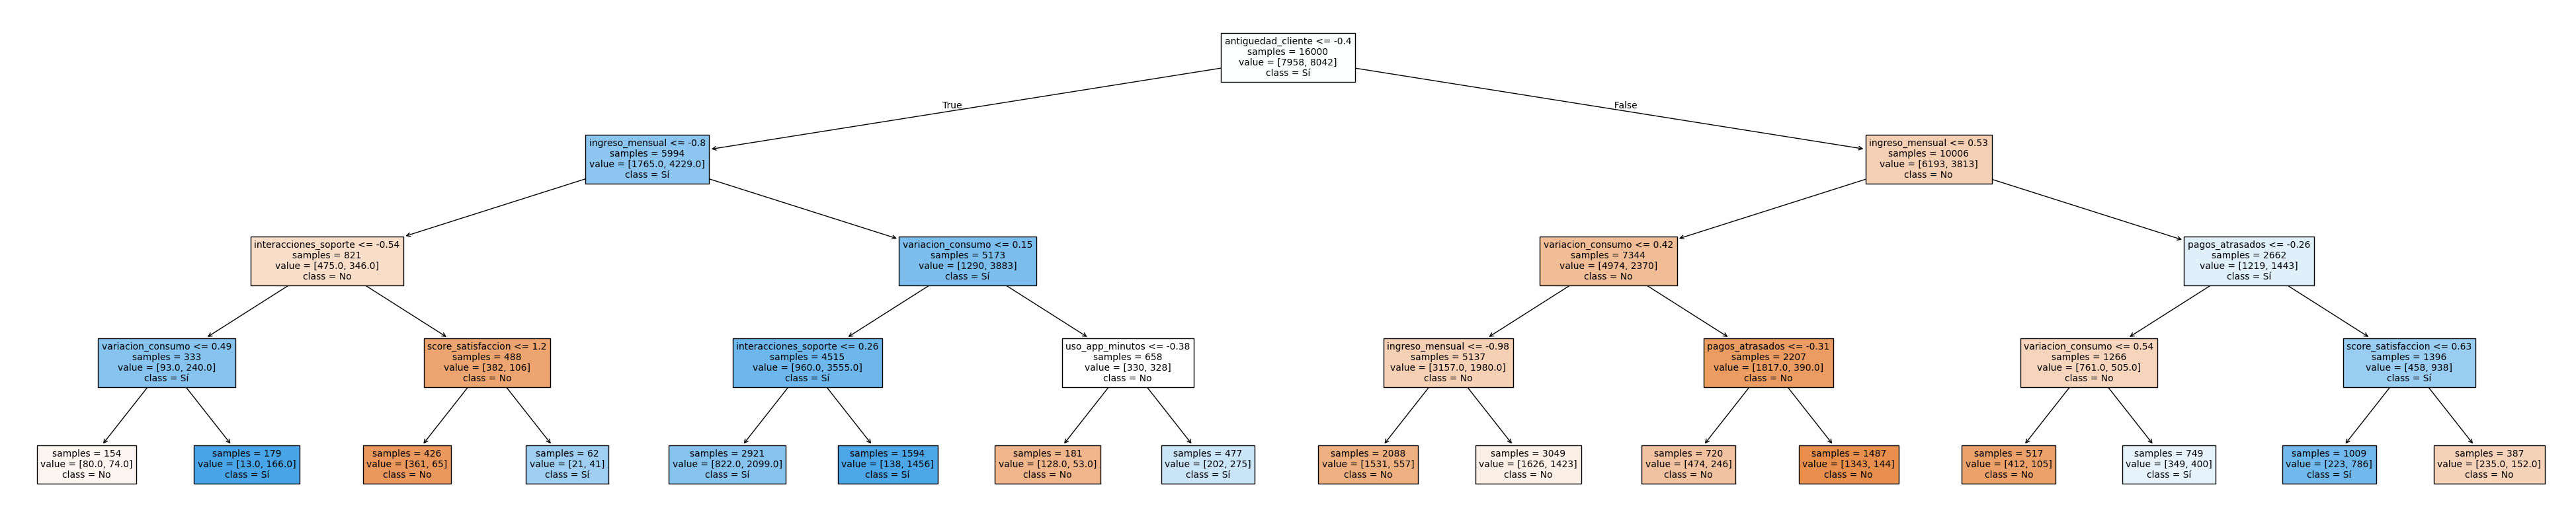

In [71]:
fig, ax = plt.subplots(figsize=(50, 10))

print(f"Profundidad del árbol: {modelo_dtc.get_depth()}")
print(f"Número de nodos terminales: {modelo_dtc.get_n_leaves()}")

plot = plot_tree(
            decision_tree = modelo_dtc,
            feature_names = X_reducido.columns,
            class_names = ["No", "Sí"],
            filled        = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )

# SVM

## Modelo 1

```python
SVC(kernel="linear", probability=True)

In [75]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_svm = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", SVC(kernel="linear", probability=True))
])

In [76]:
# Evaluación
metricas_svm = evaluar(pipeline_modelo_svm, X_train_sin_sospecha,
                       X_test_sin_sospecha, y_train_sin_sospecha,
                       y_test_sin_sospecha)
print(f"{'Accuracy':<20}: {metricas_svm['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_svm['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_svm['roc_auc']:.4f}")

Accuracy            : 0.6590
F1 Score:           : 0.6503
ROC AUC Score       : 0.7104


## Modelo 2

```python
SVC(kernel="rbf", probability=True)

In [77]:
# Crea el pipeline final (preprocesamiento + modelo)
pipeline_modelo_svm_rbf = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("preprocesador", preprocessor),
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9)),
    ("modelo", SVC(kernel="rbf", probability=True))
])

In [78]:
# Evaluación
metricas_svm_rbf = evaluar(pipeline_modelo_svm_rbf, X_train_sin_sospecha,
                       X_test_sin_sospecha, y_train_sin_sospecha,
                       y_test_sin_sospecha)
print(f"{'Accuracy':<20}: {metricas_svm_rbf['accuracy']:.4f}")
print(f"{'F1 Score:':<20}: {metricas_svm_rbf['f1']:.4f}")
print(f"{'ROC AUC Score':<20}: {metricas_svm_rbf['roc_auc']:.4f}")

Accuracy            : 0.8855
F1 Score:           : 0.8879
ROC AUC Score       : 0.9444
